In [115]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [20]:
customers_df = pd.read_csv('./data/hackathon/customers.csv')
geolocation_df = pd.read_csv('./data/hackathon/geolocation.csv')
order_payments_df = pd.read_csv('./data/hackathon/order_payments.csv')
order_reviews_df = pd.read_csv('./data/hackathon/order_reviews.csv')
orders_df = pd.read_csv('./data/hackathon/orders.csv')
orders_items_df = pd.read_csv('./data/hackathon/orders_items.csv')
product_category_name_translation_df = pd.read_csv('./data/hackathon/product_category_name_translation.csv')
products_df = pd.read_csv('./data/hackathon/products.csv')
sellers_df = pd.read_csv('./data/hackathon/sellers.csv')

C:\Users\User\AppData\Local\Temp\ipykernel_18312\1122794776.py:6: DtypeWarning: Columns (1,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  orders_items_df = pd.read_csv('./data/hackathon/orders_items.csv')


In [21]:
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [22]:
geolocation_df.head()

,Unnamed: 0,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,0,1037,-23.545621,-46.639292,sao paulo,SP
1,1,1046,-23.546081,-46.644820,sao paulo,SP
2,2,1046,-23.546129,-46.642951,sao paulo,SP
3,3,1041,-23.544392,-46.639499,sao paulo,SP
4,4,1035,-23.541578,-46.641607,sao paulo,SP


In [23]:
order_payments_df.head()

,Unnamed: 0,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [24]:
order_reviews_df.head()

,Unnamed: 0,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [25]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [26]:
orders_items_df.head()

,Unnamed: 0,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_limit_date.1,price.1,freight_value.1
0,0,00010242fe8c5a6d1ba2dd792cb16214,1.0,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-19 09:45:35,58.90,13.29
1,1,00018f77f2f0320c557190d7a144bdd3,1.0,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-05-03 11:05:13,239.90,19.93
2,2,000229ec398224ef6ca0657da4fc703e,1.0,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-18 14:48:30,199.00,17.87
3,3,00024acbcdf0a6daa1e931b038114c75,1.0,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-15 10:10:18,12.99,12.79
4,4,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-13 13:57:51,199.90,18.14


In [27]:
product_category_name_translation_df.head()

,Unnamed: 0,product_category_name,product_category_name_english
0,0,beleza_saude,health_beauty
1,1,informatica_acessorios,computers_accessories
2,2,automotivo,auto
3,3,cama_mesa_banho,bed_bath_table
4,4,moveis_decoracao,furniture_decor


In [28]:
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [29]:
sellers_df.head()

,Unnamed: 0,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


## Таблица orders_items полна дерьма(

In [30]:
orders_items_df.head()

,Unnamed: 0,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_limit_date.1,price.1,freight_value.1
0,0,00010242fe8c5a6d1ba2dd792cb16214,1.0,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-19 09:45:35,58.90,13.29
1,1,00018f77f2f0320c557190d7a144bdd3,1.0,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-05-03 11:05:13,239.90,19.93
2,2,000229ec398224ef6ca0657da4fc703e,1.0,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-18 14:48:30,199.00,17.87
3,3,00024acbcdf0a6daa1e931b038114c75,1.0,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-15 10:10:18,12.99,12.79
4,4,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-13 13:57:51,199.90,18.14


In [32]:
print(orders_items_df['price'].equals(orders_items_df['price.1']))

False


In [33]:
print(orders_items_df['shipping_limit_date'].equals(orders_items_df['shipping_limit_date.1']))

False


In [34]:
print(orders_items_df['freight_value'].equals(orders_items_df['freight_value.1']))

False


In [35]:
diff_price_mask = orders_items_df['price'] != orders_items_df['price.1']
print(orders_items_df[diff_price_mask])

        Unnamed: 0 order_id  order_item_id product_id seller_id  \
112650      112650      NaN            NaN        NaN       NaN   
112651      112651      NaN            NaN        NaN       NaN   
112652      112652      NaN            NaN        NaN       NaN   
112653      112653      NaN            NaN        NaN       NaN   
112654      112654      NaN            NaN        NaN       NaN   
...            ...      ...            ...        ...       ...   
225295      225295      NaN            NaN        NaN       NaN   
225296      225296      NaN            NaN        NaN       NaN   
225297      225297      NaN            NaN        NaN       NaN   
225298      225298      NaN            NaN        NaN       NaN   
225299      225299      NaN            NaN        NaN       NaN   

       shipping_limit_date  price  freight_value shipping_limit_date.1  \
112650                 NaN    NaN            NaN   2017-09-19 09:45:35   
112651                 NaN    NaN            Na

In [43]:
print((orders_items_df['price'].fillna(-1) == orders_items_df['price.1'].fillna(-1)).value_counts())

True     112650
False    112650
Name: count, dtype: int64


In [45]:
orders_items_df['price.1'].fillna(-1).value_counts()

price.1
59.90      4962
69.90      3974
49.90      3906
89.90      3096
99.90      2864
           ... 
1369.90       2
108.24        2
1224.99       2
24.52         2
736.00        2
Name: count, Length: 5968, dtype: int64

## оставляем price.1 -> переименовываем в price

In [49]:
diff_shipping_limit = orders_items_df['shipping_limit_date'] != orders_items_df['shipping_limit_date.1']
print(orders_items_df[diff_price_mask])

        Unnamed: 0 order_id  order_item_id product_id seller_id  \
112650      112650      NaN            NaN        NaN       NaN   
112651      112651      NaN            NaN        NaN       NaN   
112652      112652      NaN            NaN        NaN       NaN   
112653      112653      NaN            NaN        NaN       NaN   
112654      112654      NaN            NaN        NaN       NaN   
...            ...      ...            ...        ...       ...   
225295      225295      NaN            NaN        NaN       NaN   
225296      225296      NaN            NaN        NaN       NaN   
225297      225297      NaN            NaN        NaN       NaN   
225298      225298      NaN            NaN        NaN       NaN   
225299      225299      NaN            NaN        NaN       NaN   

       shipping_limit_date  price  freight_value shipping_limit_date.1  \
112650                 NaN    NaN            NaN   2017-09-19 09:45:35   
112651                 NaN    NaN            Na

In [50]:
print((orders_items_df['shipping_limit_date'].fillna(-1) == orders_items_df['shipping_limit_date.1'].fillna(-1)).value_counts())

True     112650
False    112650
Name: count, dtype: int64


In [53]:
orders_items_df['shipping_limit_date.1'].fillna(-1).value_counts()

shipping_limit_date.1
2017-07-21 18:25:23    42
2018-03-01 02:50:48    42
2017-08-30 14:30:23    40
2017-02-03 21:44:49    30
2017-12-21 02:30:41    30
                       ..
2017-10-02 03:56:18     2
2018-01-04 16:09:20     2
2018-04-25 16:55:28     2
2017-11-29 22:19:33     2
2018-06-12 17:10:13     2
Name: count, Length: 93318, dtype: int64

In [54]:
print((orders_items_df['freight_value'].fillna(-1) == orders_items_df['freight_value.1'].fillna(-1)).value_counts())

True     112650
False    112650
Name: count, dtype: int64


In [62]:
orders_items_df['freight_value.1'].fillna(-1).value_counts()

freight_value.1
15.10    7414
7.78     4524
14.10    3750
11.85    3692
18.23    3150
         ... 
57.83       2
80.47       2
70.92       2
42.85       2
6.37        2
Name: count, Length: 6999, dtype: int64

In [71]:
orders_df['order_status'].fillna('unknown').value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## А как зависит статус от города продавца?

In [82]:
products_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [79]:
orders_items_df

,Unnamed: 0,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_limit_date.1,price.1,freight_value.1
0,0,00010242fe8c5a6d1ba2dd792cb16214,1.0,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-19 09:45:35,58.90,13.29
1,1,00018f77f2f0320c557190d7a144bdd3,1.0,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-05-03 11:05:13,239.90,19.93
2,2,000229ec398224ef6ca0657da4fc703e,1.0,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-18 14:48:30,199.00,17.87
3,3,00024acbcdf0a6daa1e931b038114c75,1.0,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-15 10:10:18,12.99,12.79
4,4,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...,...,...,...,...
225295,225295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-05-02 04:11:01,299.99,43.41
225296,225296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-07-20 04:31:48,350.00,36.53
225297,225297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-10-30 17:14:25,99.90,16.95
225298,225298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-08-21 00:04:32,55.99,8.72


In [83]:
order_items_with_product_df = pd.merge(orders_items_df, products_df, on='product_id', how='left')

In [99]:
order_items_with_product_df

,Unnamed: 0,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_limit_date.1,price.1,freight_value.1,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,0,00010242fe8c5a6d1ba2dd792cb16214,1.0,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,1,00018f77f2f0320c557190d7a144bdd3,1.0,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,2,000229ec398224ef6ca0657da4fc703e,1.0,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,3,00024acbcdf0a6daa1e931b038114c75,1.0,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,4,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225295,225295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-05-02 04:11:01,299.99,43.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225296,225296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-07-20 04:31:48,350.00,36.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225297,225297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-10-30 17:14:25,99.90,16.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225298,225298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-08-21 00:04:32,55.99,8.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [91]:
order_items_with_product_with_sellers_df = pd.merge(order_items_with_product_df, sellers_df, on='seller_id', how='left')

In [104]:
order_items_with_product_with_sellers_with_orders_df = pd.merge(order_items_with_product_with_sellers_df, orders_df, on='order_id', how='left')

In [105]:
order_items_with_product_with_sellers_with_orders_df

,Unnamed: 0_x,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,shipping_limit_date.1,price.1,...,seller_zip_code_prefix,seller_city,seller_state,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,0,00010242fe8c5a6d1ba2dd792cb16214,1.0,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,2017-09-19 09:45:35,58.90,...,27277.0,volta redonda,SP,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29 00:00:00
1,1,00018f77f2f0320c557190d7a144bdd3,1.0,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,2017-05-03 11:05:13,239.90,...,3471.0,sao paulo,SP,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15 00:00:00
2,2,000229ec398224ef6ca0657da4fc703e,1.0,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,2018-01-18 14:48:30,199.00,...,37564.0,borda da mata,MG,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05 00:00:00
3,3,00024acbcdf0a6daa1e931b038114c75,1.0,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,2018-08-15 10:10:18,12.99,...,14403.0,franca,SP,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20 00:00:00
4,4,00042b26cf59d7ce69dfabb4e55b4fd9,1.0,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,2017-02-13 13:57:51,199.90,...,87900.0,loanda,PR,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225295,225295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-05-02 04:11:01,299.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225296,225296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-07-20 04:31:48,350.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225297,225297,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-10-30 17:14:25,99.90,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
225298,225298,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-08-21 00:04:32,55.99,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [122]:
order_items_with_product_with_sellers_with_orders_df.drop(['price', 'shipping_limit_date', 'freight_value'], axis=1, inplace=True)

In [124]:
order_items_with_product_with_sellers_with_orders_df = order_items_with_product_with_sellers_with_orders_df.rename(columns={'price.1': 'price', 'shipping_limit_date': 'shipping_limit_date', 'freight_value.1': 'freight_value'})

In [134]:
order_status_seller_state_group = order_items_with_product_with_sellers_with_orders_df.groupby(['order_status', 'seller_state']).size().reset_index(name='order_count')

C:\Users\User\anaconda3\Lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


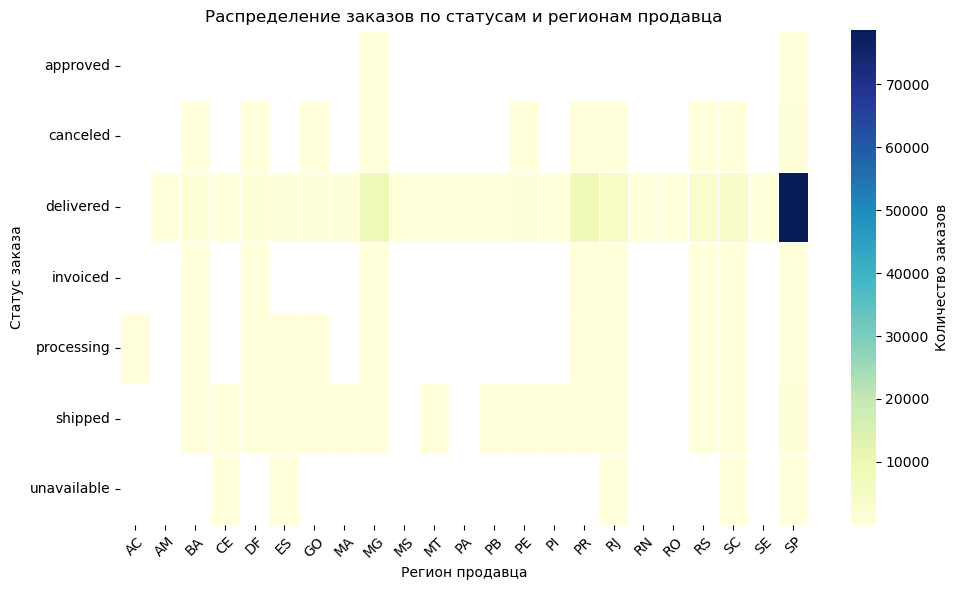

In [135]:
pivot_table = order_status_seller_state_group.pivot(
    index='order_status',
    columns='seller_state',
    values='order_count'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_table,
    annot=True,      # Показывать числа в ячейках
    fmt="d",        # Целые числа (без десятичных)
    cmap="YlGnBu",  # Цветовая схема
    linewidths=0.5,
    cbar_kws={'label': 'Количество заказов'}
)

plt.title("Распределение заказов по статусам и регионам продавца")
plt.xlabel("Регион продавца")
plt.ylabel("Статус заказа")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

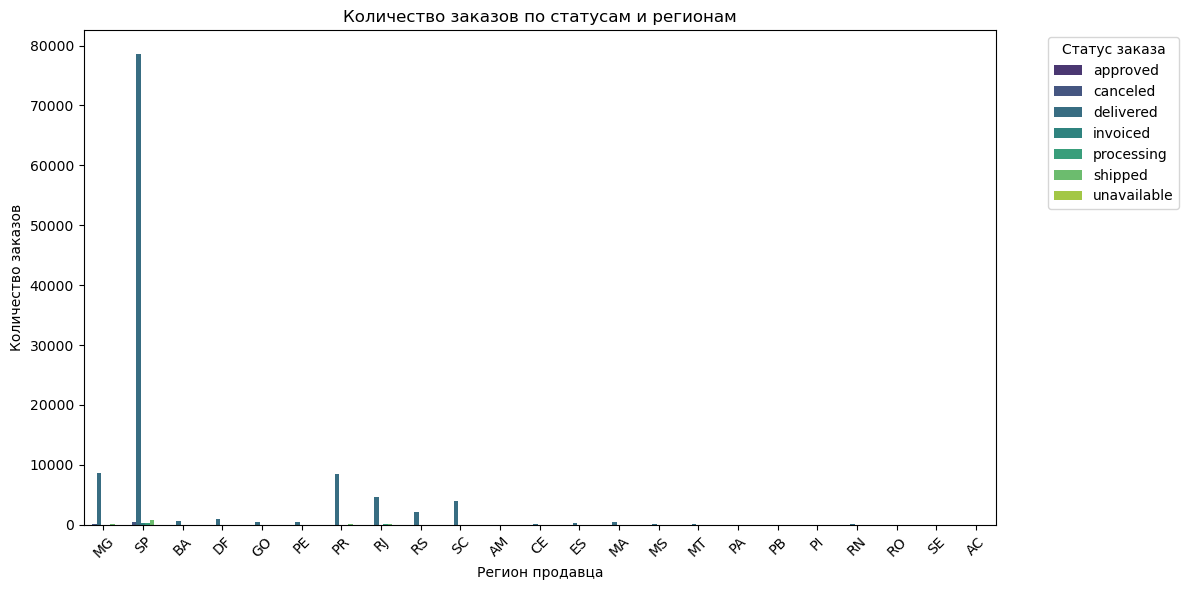

In [137]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=order_status_seller_state_group,
    x='seller_state',
    y='order_count',
    hue='order_status',
    palette="viridis"
)

plt.title("Количество заказов по статусам и регионам")
plt.xlabel("Регион продавца")
plt.ylabel("Количество заказов")
plt.legend(title='Статус заказа', bbox_to_anchor=(1.05, 1))  # Выносим легенду справа
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [127]:
clean_contingency_table = pd.crosstab(order_items_with_product_with_sellers_with_orders_df['order_status'], order_items_with_product_with_sellers_with_orders_df['seller_state']).fillna({
    'order_status': 'Unknown',
    'seller_state': 'Unknown'
})


chi2, p_value, _, _ = chi2_contingency(clean_contingency_table)
print(f"p-value = {p_value:.3f}")

if p_value < 0.05:
    print("Есть статистическая зависимость (p < 0.05)")
else:
    print("Нет значимой зависимости (p >= 0.05)")

p-value = 0.000
Есть статистическая зависимость (p < 0.05)


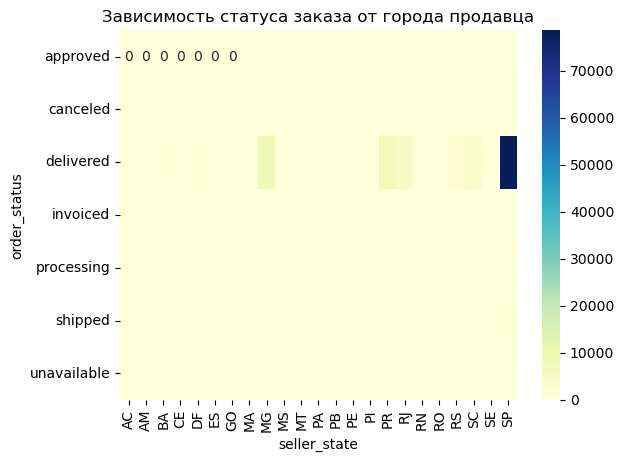

In [128]:
sns.heatmap(clean_contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Зависимость статуса заказа от города продавца')
plt.show()

In [ ]:
order_items_with_product_with_sellers_with_orders_df